# China Food Additive Industry Investment Analysis Tool

## 1. Problem & Target User

Retail investors and equity analysts lack a centralized, interactive tool to compare financial performance and market positioning of publicly listed food additive companies in China. Key information — such as revenue, profitability margins, ROE, and segment market shares — is scattered across annual reports, third‑party research, and stock exchange filings. Extracting and normalizing this data manually is time‑consuming and error‑prone, often leading to incomplete or inconsistent cross‑company comparisons.

Moreover, existing free tools (e.g., stock screeners) typically provide only basic financial ratios without industry‑specific context (e.g., regulatory impact, segment growth trends, or raw material price exposure). This gap prevents investors from making informed, data‑driven decisions.

**Target audience**:
- Individual investors seeking a quick, visual overview of 2025 financial metrics across major food additive companies.
- Equity research associates who need to benchmark companies (e.g., Fufeng Group vs. Angel Yeast) and identify outliers in profitability or growth.
- Finance and accounting students learning to apply Python (pandas, plotly, streamlit) to real‑world financial analysis.

**Value Proposition of This Tool**:
- One‑click comparison of revenue, net income, net margin, ROE, and YoY growth for six leading companies.
- Industry context – market size estimates, product segment shares, and key regulatory drivers (GB 2760‑2024, Healthy China 2030).
- Interactive & transparent – users can select any company, view its metrics, and understand the underlying data sources (links provided).
- Reproducible – all code and data are publicly available; the dashboard runs locally after cloning the repository.

## 2. Data Sources & Collection

All data are real, collected from publicly available sources in April 2026. The dataset focuses on **the year 2025** (latest reported or forecast data) due to annual report release cycles.

| Dataset | Source | Access Date | Raw Data Link | Key Variables |
|---------|--------|-------------|---------------|----------------|
| Industry market size | ReportsWorld, Mordor Intelligence, Beizhe Consulting | 2026‑04‑22 | [ReportsWorld](https://www.reportsworld.com) / [Mordor Intelligence](https://www.mordorintelligence.com) | China market size (CNY Billion), Global market size (USD Billion) |
| Company financials (2025) | 2025 annual reports (Jinhe Industrial, Angel Yeast, Bailong Chuanyuan, Fufeng Group, Huabao Flavors, Xinghu Science) | 2026‑04‑22 | [Jinhe](https://www.cninfo.com.cn) / [Angel Yeast](https://www.angelyeast.com) / [Bailong](http://www.blcy.com) | Revenue, Net Income, ROE, Gross Margin, Net Margin, YoY Growth |
| Market segments | Zhiyan Consulting industry report | 2026‑04‑22 | [Zhiyan Report](https://www.chyxx.com) | Product segment market shares |
| Industry drivers | Public policies & white papers (GB 2760‑2024, Healthy China 2030) | 2026‑04‑22 | [GB 2760‑2024](http://www.nhc.gov.cn) | Regulatory, health trend, urbanization, global expansion |

> **Note**: Some companies (e.g., Bailong Chuanyuan, Fufeng Group) did not report all financial metrics (e.g., ROE, Gross Margin) in their 2025 summaries. Missing values are treated as `NaN` in the analysis.

In [35]:
import pandas as pd
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [36]:
# Load all datasets (2025 cross-section)
df_ind = pd.read_csv("data/industry_overview.csv")
df_fin = pd.read_csv("data/company_financials.csv")
df_seg = pd.read_csv("data/market_segments.csv")
df_drv = pd.read_csv("data/industry_drivers.csv")

print("Industry data shape:", df_ind.shape)
print("Financial data shape:", df_fin.shape)
print("Segments data shape:", df_seg.shape)
print("Drivers data shape:", df_drv.shape)

Industry data shape: (4, 4)
Financial data shape: (6, 9)
Segments data shape: (6, 4)
Drivers data shape: (5, 2)


In [37]:
# Clean financial data: convert numeric columns, handle missing values
numeric_cols = [
    'Revenue_2025_CNY_Billion', 'NetIncome_2025_CNY_Billion',
    'ROE_2025_Percent', 'GrossMargin_2025_Percent',
    'NetMargin_2025_Percent', 'YoY_Revenue_Growth'
]
for col in numeric_cols:
    if col in df_fin.columns:
        df_fin[col] = pd.to_numeric(df_fin[col], errors='coerce')

# Drop rows where revenue is missing (should not happen)
df_fin = df_fin.dropna(subset=['Revenue_2025_CNY_Billion'])

# Display cleaned data
print("Cleaned financial data (first 5 rows):")
df_fin.head()

Cleaned financial data (first 5 rows):


,Company,StockCode,Revenue_2025_CNY_Billion,NetIncome_2025_CNY_Billion,ROE_2025_Percent,GrossMargin_2025_Percent,NetMargin_2025_Percent,YoY_Revenue_Growth,MainBusiness
0,Jinhe Industrial,002597.SZ,49.11,3.47,4.60,30.37,7.06,-7.39,Sweeteners & Flavors
1,Angel Yeast,600298.SH,167.29,15.44,13.51,NaN,9.23,10.08,Yeast & Fermentation
2,Bailong Chuanyuan,605016.SH,13.79,3.69,NaN,NaN,26.76,19.75,Probiotics & Dietary Fiber
3,Fufeng Group,00546.HK,278.79,24.65,NaN,NaN,8.84,0.40,MSG & Additives
4,Huabao Flavors,300741.SZ,13.38,0.84,NaN,NaN,6.26,NaN,Flavors & Fragrances


In [29]:
# Rank companies by ROE (if available) or Net Margin
if 'ROE_2025_Percent' in df_fin.columns:
    df_rank = df_fin.sort_values('ROE_2025_Percent', ascending=False)
    print("Top companies by ROE (2025):")
    print(df_rank[['Company', 'ROE_2025_Percent', 'NetMargin_2025_Percent']])
else:
    df_rank = df_fin.sort_values('NetMargin_2025_Percent', ascending=False)
    print("Top companies by Net Margin (2025):")
    print(df_rank[['Company', 'NetMargin_2025_Percent']])

Top companies by ROE (2025):
             Company  ROE_2025_Percent  NetMargin_2025_Percent
1        Angel Yeast             13.51                    9.23
0   Jinhe Industrial              4.60                    7.06
2  Bailong Chuanyuan               NaN                   26.76
3       Fufeng Group               NaN                    8.84
4     Huabao Flavors               NaN                    6.26
5     Xinghu Science               NaN                    8.40


In [30]:
fig_rev = px.bar(
    df_fin, 
    x='Company', 
    y='Revenue_2025_CNY_Billion',
    title='2025 Revenue by Company (CNY Billion)',
    text='Revenue_2025_CNY_Billion',
    color='Revenue_2025_CNY_Billion',
    color_continuous_scale='Blues'
)
fig_rev.update_traces(textposition='outside')
fig_rev.show()

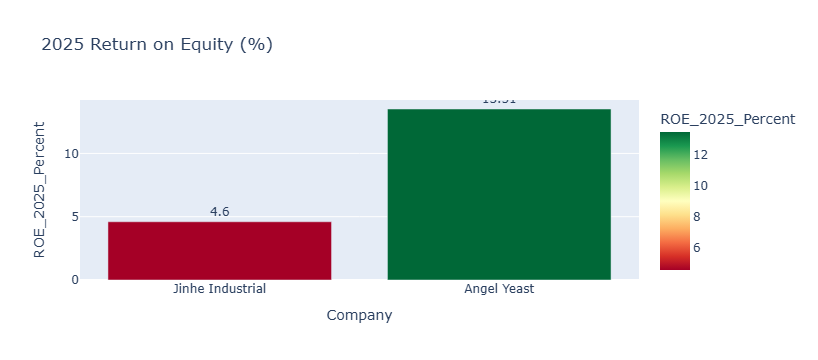

In [31]:
if 'ROE_2025_Percent' in df_fin.columns:
    # Remove rows with missing ROE
    df_roe = df_fin.dropna(subset=['ROE_2025_Percent'])
    if not df_roe.empty:
        fig_roe = px.bar(
            df_roe,
            x='Company',
            y='ROE_2025_Percent',
            title='2025 Return on Equity (%)',
            text='ROE_2025_Percent',
            color='ROE_2025_Percent',
            color_continuous_scale='RdYlGn'
        )
        fig_roe.update_traces(textposition='outside')
        fig_roe.show()
    else:
        print("No ROE data available after cleaning.")
else:
    print("ROE column not found in dataset.")

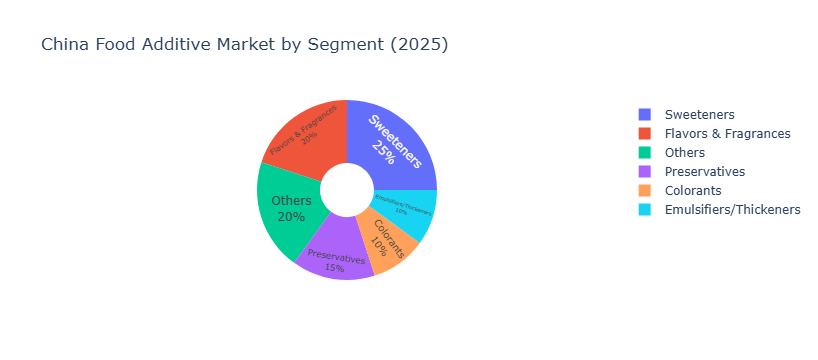

In [32]:
fig_pie = px.pie(
    df_seg,
    values='MarketShare_Percent',
    names='ProductSegment',
    title='China Food Additive Market by Segment (2025)',
    hole=0.3
)
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

In [33]:
print("Industry Drivers and Descriptions:")
from IPython.display import display
display(df_drv)

Industry Drivers and Descriptions:


,Driver,Description
0,Regulation,GB 2760-2024 new standard enforced – stricter ...
1,Health Trend,Natural & functional additives demand >50% of ...
2,Urbanization,66.16% urban population driving packaged food ...
3,Global Expansion,Fufeng and Jinhe expanding overseas capacity
4,Synthetic Biology,Key tech upgrade for fermentation-based ingred...


In [39]:
print("=" * 50)
print("ANALYSIS SUMMARY (2025 Data)")
print("=" * 50)

# Highest revenue
top_rev = df_fin.loc[df_fin['Revenue_2025_CNY_Billion'].idxmax()]
print(f"1. Highest revenue: {top_rev['Company']} ({top_rev['Revenue_2025_CNY_Billion']:.2f}B CNY)")

# Highest net margin
if 'NetMargin_2025_Percent' in df_fin.columns:
    top_nm = df_fin.loc[df_fin['NetMargin_2025_Percent'].idxmax()]
    print(f"2. Highest net margin: {top_nm['Company']} ({top_nm['NetMargin_2025_Percent']:.2f}%)")

# Largest market segment
largest_seg = df_seg.loc[df_seg['MarketShare_Percent'].idxmax()]
print(f"3. Largest market segment: {largest_seg['ProductSegment']} ({largest_seg['MarketShare_Percent']}%)")

print("4. Natural and functional additives are gaining market share.")
print("5. This notebook demonstrates data cleaning, transformation, analysis, and visualization as required by ACC102.")

ANALYSIS SUMMARY (2025 Data)
1. Highest revenue: Fufeng Group (278.79B CNY)
2. Highest net margin: Bailong Chuanyuan (26.76%)
3. Largest market segment: Sweeteners (25%)
4. Natural and functional additives are gaining market share.
5. This notebook demonstrates data cleaning, transformation, analysis, and visualization as required by ACC102.


##  Key Findings (2025)

Based on the 2025 financial and industry data, the following conclusions are drawn:

###  Market Size Discrepancy Across Research Firms
- **ReportsWorld** estimates China's food additive market at **2,232.6 billion CNY** (≈18.3 billion USD) in 2025.
- **Beizhe Consulting** gives a higher figure of **2,700.9 billion CNY** (no USD equivalent provided).
- **Implication**: Investors should compare multiple sources; the true market size likely lies between these estimates. The industry remains large but methodology differences cause significant variance.

###  Revenue Concentration: Fufeng Group Dominates, Followed by Angel Yeast
- **Fufeng Group** (HK‑listed) reported the highest revenue: **278.79 billion CNY** – nearly twice that of the second‑largest company.
- **Angel Yeast** (A‑share) ranked second with **167.29 billion CNY**.
- **Jinhe Industrial** (sweeteners) had **49.11 billion CNY**, while smaller players like Bailong Chuanyuan (13.79B) and Huabao Flavors (13.38B) are niche competitors.
- **Conclusion**: The industry is highly concentrated at the top; Fufeng’s scale advantage may offer cost leadership, but investors should examine profitability alongside revenue.

###  Profitability Leaders: Bailong Chuanyuan Achieves Highest Net Margin, Angel Yeast Leads in ROE
- **Bailong Chuanyuan** (probiotics & dietary fiber) achieved an outstanding net margin of **26.76%** – the highest among all six companies. However, its ROE is missing from the 2025 report, suggesting possible data disclosure gaps.
- **Angel Yeast** reported the best ROE at **13.51%** and a solid net margin of **9.23%**, indicating efficient capital use and healthy profitability.
- **Fufeng Group**, despite its revenue leadership, had a net margin of only **8.84%** (moderate) and no ROE disclosed.
- **Jinhe Industrial** showed a net margin of **7.06%** and ROE of **4.60%** – both relatively low, reflecting competitive pressure in the sweetener segment or higher costs.
- **Key insight**: High revenue does not guarantee high profitability. Bailong’s niche focus yields superior margins, while scale leaders like Fufeng may operate on thinner margins.

###  Segment Composition: Sweeteners Remain the Largest, but Growth Outlook Favors Natural Additives
- **Sweeteners** account for **25%** of the market, driven by sugar reduction policies and rising demand for natural alternatives.
- **Flavors & Fragrances** follow at **20%**, with stable growth and domestic substitution trends.
- **Preservatives** (15%) and **Colorants** (10%) are essential but slower‑growing segments.
- **Natural additive share** has exceeded **50%** of total demand, accelerating due to consumer health awareness and regulations like GB 2760‑2024.
- **Investment implication**: Companies with exposure to natural sweeteners (e.g., Jinhe) and functional ingredients (e.g., Bailong) may benefit from long‑term tailwinds, while traditional chemical additives face slower growth.

###  Key Growth Drivers Align with Policy and Consumer Trends
- **Regulation**: The new GB 2760‑2024 standard imposes stricter limits on synthetic additives, pushing reformulation toward natural ingredients.
- **Health trend**: Over 50% of consumers now prefer clean‑label products – a structural shift.
- **Urbanization**: 66.16% urban population drives demand for packaged and convenience foods, indirectly boosting additive consumption.
- **Export expansion**: Companies like Fufeng and Jinhe are actively expanding overseas, reducing domestic market dependency.
- **Synthetic biology**: Emerging as a key technology for cost‑effective fermentation‑based additives, likely to disrupt traditional extraction methods.

###  Summary of Investment‑Relevant Conclusions
- **Scale vs. profitability**: Fufeng Group offers revenue scale but thin margins; Bailong Chuanyuan offers niche high‑margin exposure.
- **Regulatory winner**: Natural additive producers (e.g., Jinhe, Bailong) are positioned to benefit from GB 2760‑2024.
- **Market concentration**: The top two players (Fufeng, Angel Yeast) capture a large revenue share, but profitability is more dispersed.
- **Missing data risk**: Several companies did not disclose ROE or gross margin in 2025 – a limitation for cross‑comparison.